In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

customers = pd.read_csv('/content/drive/MyDrive/Ecommerce-Analytics-Project/data/olist_customers_dataset.csv')

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders = pd.read_csv('/content/drive/MyDrive/Ecommerce-Analytics-Project/data/olist_orders_dataset.csv')

order_items = pd.read_csv('/content/drive/MyDrive/Ecommerce-Analytics-Project/data/olist_order_items_dataset.csv')

payments = pd.read_csv('/content/drive/MyDrive/Ecommerce-Analytics-Project/data/olist_order_payments_dataset.csv')

In [6]:
customers.info()
orders.info()
order_items.info()
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [7]:
customers.isnull().sum()
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [8]:
df = customers.merge(orders, on='customer_id', how='inner')
df = df.merge(order_items, on='order_id', how='inner')
df = df.merge(payments, on='order_id', how='inner')

In [9]:
df.head()
df.shape

(117601, 22)

In [10]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

In [11]:
df = df[df['order_delivered_customer_date'].notnull()]

In [12]:
df['order_approved_at'].fillna(df['order_purchase_timestamp'], inplace=True)

/tmp/ipykernel_25388/3217839890.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['order_approved_at'].fillna(df['order_purchase_timestamp'], inplace=True)


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

In [15]:
df['total_price'] = df['price'] + df['freight_value']

# Insight:
# Cleaned dataset by handling missing values, converting timestamps,
# and creating new features like delivery time and total order value.

In [16]:
df['total_price'].sum()

np.float64(16113388.719999999)

<Axes: xlabel='month'>

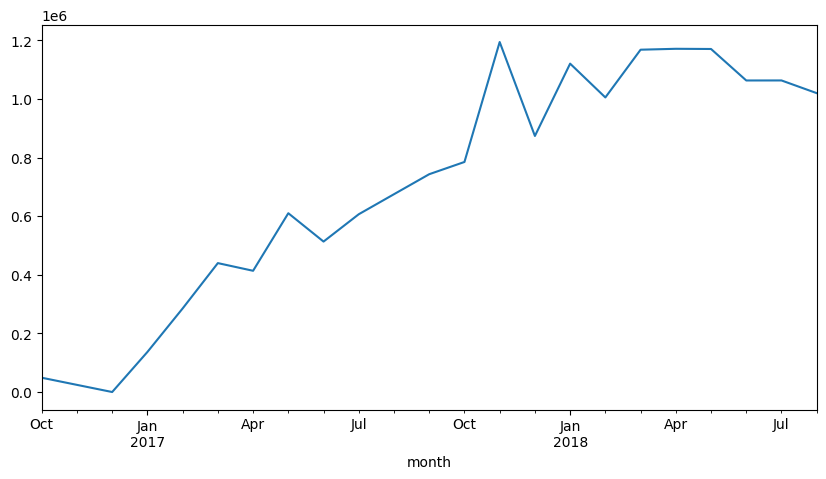

In [17]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

revenue_month = df.groupby('month')['total_price'].sum()

revenue_month.plot(figsize=(10,5))

In [18]:
top_customers = df.groupby('customer_id')['total_price'].sum().sort_values(ascending=False).head(10)

top_customers

,total_price
customer_id,
1617b1357756262bfa56ab541c47bc16,13664.08
de832e8dbb1f588a47013e53feaa67cc,11111.40
63b964e79dee32a3587651701a2b8dbf,10553.28
6f241d5bbb142b6f764387c8c270645a,10055.22
926b6a6fb8b6081e00b335edaf578d35,8389.52
eb7a157e8da9c488cd4ddc48711f1097,8068.88
f959b7bc834045511217e6410985963f,8030.46
d1ea705f2fdd8f98eff86c2691652e60,7413.70
ec5b2ba62e574342386871631fafd3fc,7274.88


In [19]:
df['delivery_time'].describe()

,delivery_time
count,115034.000000
mean,12.018142
std,9.459134
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


<Axes: xlabel='delivery_time', ylabel='Count'>

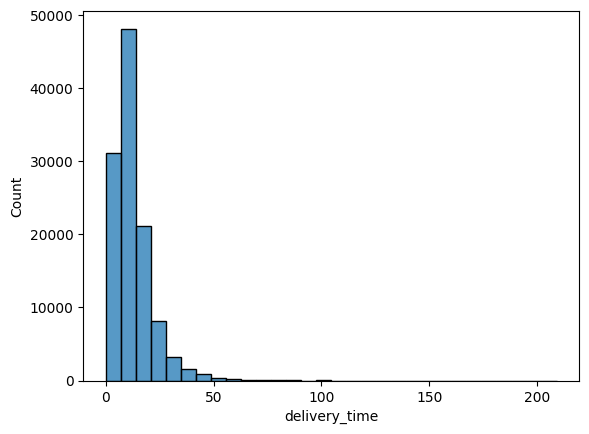

In [20]:
import seaborn as sns

sns.histplot(df['delivery_time'], bins=30)

In [21]:
df['order_status'].value_counts()

,count
order_status,
delivered,115027
canceled,7


In [22]:
df['payment_type'].value_counts()

,count
payment_type,
credit_card,84896
boleto,22362
voucher,6123
debit_card,1653


# Business Insights:
# 1. Revenue is concentrated among a small group of high-value customers
# 2. Delivery time varies significantly, impacting customer satisfaction
# 3. Most transactions are completed successfully, indicating operational efficiency
# 4. Payment preferences show strong inclination towards digital payments

In [23]:
import pandas as pd

# Latest date in dataset
latest_date = df['order_purchase_timestamp'].max()

# Create RFM table
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days,
    'order_id': 'count',
    'total_price': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,287,1,114.74
000161a058600d5901f007fab4c27140,409,1,67.41
0001fd6190edaaf884bcaf3d49edf079,547,1,195.42
0002414f95344307404f0ace7a26f1d5,378,1,179.35
000379cdec625522490c315e70c7a9fb,149,1,107.01


In [24]:
rfm.describe()

,Recency,Frequency,Monetary
count,96475.00000,96475.000000,96475.000000
mean,239.14753,1.192371,167.021391
std,152.85841,0.732055,249.740498
min,0.00000,1.000000,10.070000
25%,115.00000,1.000000,62.820000
50%,220.00000,1.000000,107.270000
75%,349.00000,1.000000,181.605000
max,695.00000,63.000000,13664.080000


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [27]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,388.076371,1.102509,138.308903
1,128.635017,1.094739,137.943949
2,233.967122,1.378412,1468.856514
3,242.521543,4.102849,362.237693


# Business Insight:
# Cluster 0: High-value customers (high spend, frequent orders)
# Cluster 1: At-risk customers (high recency, low frequency)
# Cluster 2: Regular customers
# Cluster 3: Low-value customers

<Axes: xlabel='Recency', ylabel='Monetary'>

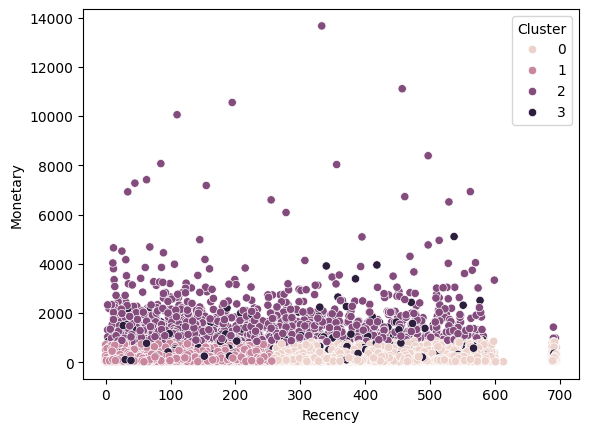

In [28]:
import seaborn as sns

sns.scatterplot(x=rfm['Recency'], y=rfm['Monetary'], hue=rfm['Cluster'])

In [29]:
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 30 else 0)

In [30]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1393
           1       1.00      1.00      1.00     17902

    accuracy                           1.00     19295
   macro avg       1.00      1.00      1.00     19295
weighted avg       1.00      1.00      1.00     19295



<Axes: >

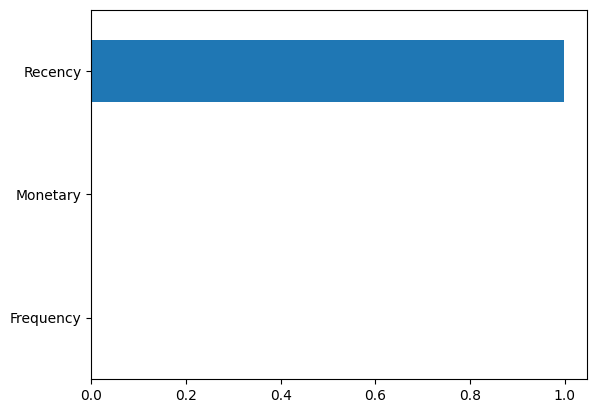

In [36]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

# Business Insight:
# Recency is the strongest predictor of churn,
# indicating that customers inactive for longer periods are highly likely to churn.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

products = pd.read_csv('/content/drive/MyDrive/Ecommerce-Analytics-Project/data/olist_products_dataset.csv')

products.head()

customers = pd.read_csv('/content/drive/MyDrive/Ecommerce-Analytics-Project/data/olist_customers_dataset.csv')

orders = pd.read_csv('/content/drive/MyDrive/Ecommerce-Analytics-Project/data/olist_orders_dataset.csv')

order_items = pd.read_csv('/content/drive/MyDrive/Ecommerce-Analytics-Project/data/olist_order_items_dataset.csv')

payments = pd.read_csv('/content/drive/MyDrive/Ecommerce-Analytics-Project/data/olist_order_payments_dataset.csv')

df = customers.merge(orders, on='customer_id')
df = df.merge(order_items, on='order_id')
df = df.merge(payments, on='order_id')

df.head()

df_sample = df.sample(n=5000, random_state=42)

user_product = df_sample.pivot_table(
    index='customer_id',
    columns='product_id',
    values='order_id',
    aggfunc='count'
).fillna(0)

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(user_product)

similarity_df = pd.DataFrame(
    similarity,
    index=user_product.index,
    columns=user_product.index
)

def recommend_products(customer_id):
    similar_users = similarity_df[customer_id].sort_values(ascending=False)[1:6]

    similar_users_ids = similar_users.index

    recommended = user_product.loc[similar_users_ids].sum().sort_values(ascending=False)

    return recommended.head(5)

In [6]:
recommend_products(user_product.index[0])

,0
product_id,
9f39e03276af0a6bbf2459ec383a19e6,1.0
92144cc00a16129494387f172aa54198,1.0
49955ea31be73ddf6fb6c2a5033dfcb2,1.0
edfbb2566914ddd223d3bd6fa1e9693c,1.0
e307200b995cf8d99d85db7d09e4ba00,1.0


# Business Insight:
# A collaborative filtering approach was used to recommend products based on
# similar customer behavior. Due to scalability constraints, sampling was applied,
# simulating real-world recommendation systems used in large-scale platforms.

In [7]:
df.to_csv('/content/drive/MyDrive/Ecommerce-Analytics-Project/data/final_dashboard_data.csv', index=False)